Using device: cuda
[INFO] Classes (4): ['Angry', 'Other', 'Sad', 'happy']
[INFO] Train :   700 images
[INFO] Val   :   150 images
[INFO] Test  :   150 images


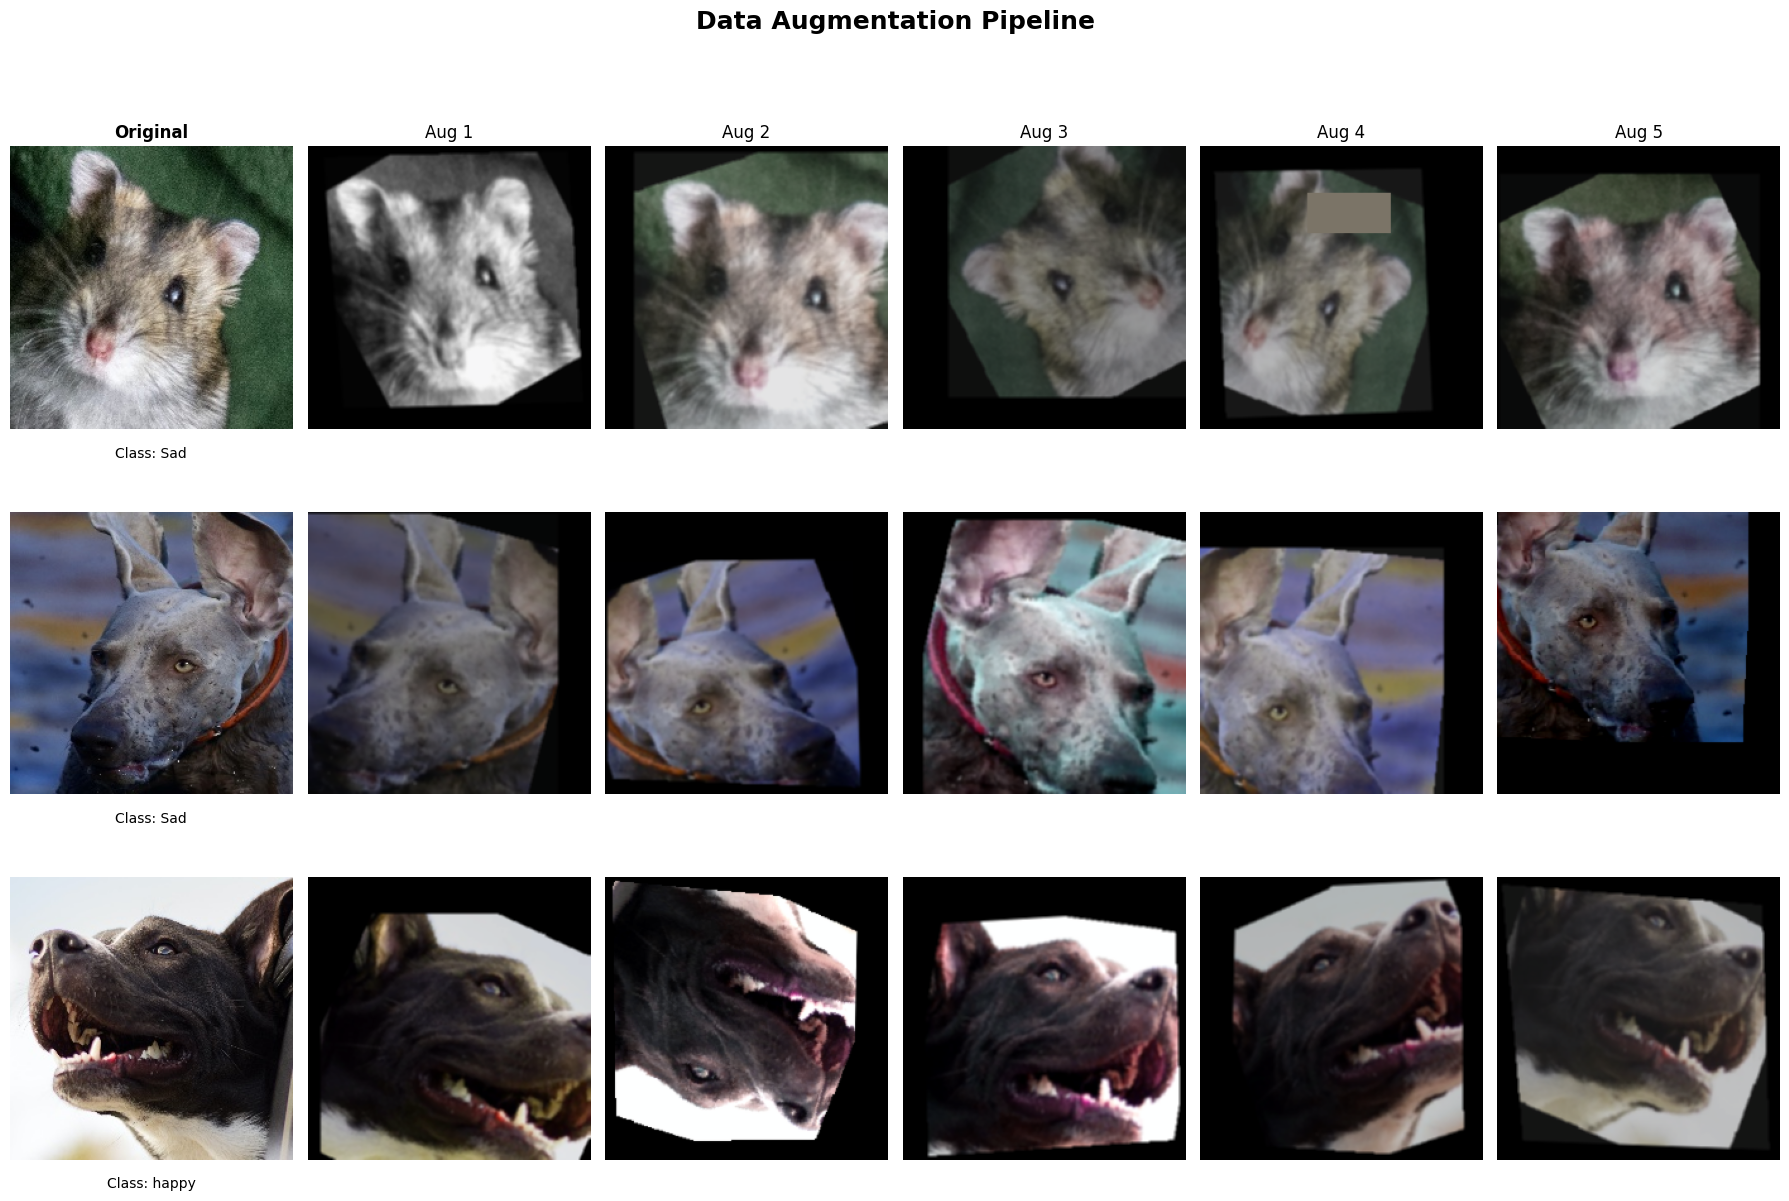


############################################################
  Initialising VGG16
############################################################

  Training VGG16  |  134,285,380 parameters
  Optimizer : SGD  |  LR: 0.01  |  Momentum: 0.9
Epoch [01/50]  Train Loss: 1.5316  Acc: 0.2700  |  Val Loss: 1.3879  Acc: 0.2600  |  LR: 9.99e-03
  ✓ New best val accuracy: 0.2600
Epoch [02/50]  Train Loss: 1.5207  Acc: 0.2629  |  Val Loss: 1.4562  Acc: 0.2600  |  LR: 9.96e-03
Epoch [03/50]  Train Loss: 1.5318  Acc: 0.2571  |  Val Loss: 1.3932  Acc: 0.2667  |  LR: 9.91e-03
  ✓ New best val accuracy: 0.2667
Epoch [04/50]  Train Loss: 1.5001  Acc: 0.2700  |  Val Loss: 1.3542  Acc: 0.3333  |  LR: 9.84e-03
  ✓ New best val accuracy: 0.3333
Epoch [05/50]  Train Loss: 1.4902  Acc: 0.2614  |  Val Loss: 1.3831  Acc: 0.2800  |  LR: 9.76e-03
Epoch [06/50]  Train Loss: 1.4707  Acc: 0.2729  |  Val Loss: 1.3741  Acc: 0.3000  |  LR: 9.65e-03
Epoch [07/50]  Train Loss: 1.4686  Acc: 0.2814  |  Val Loss: 1.3497  Acc

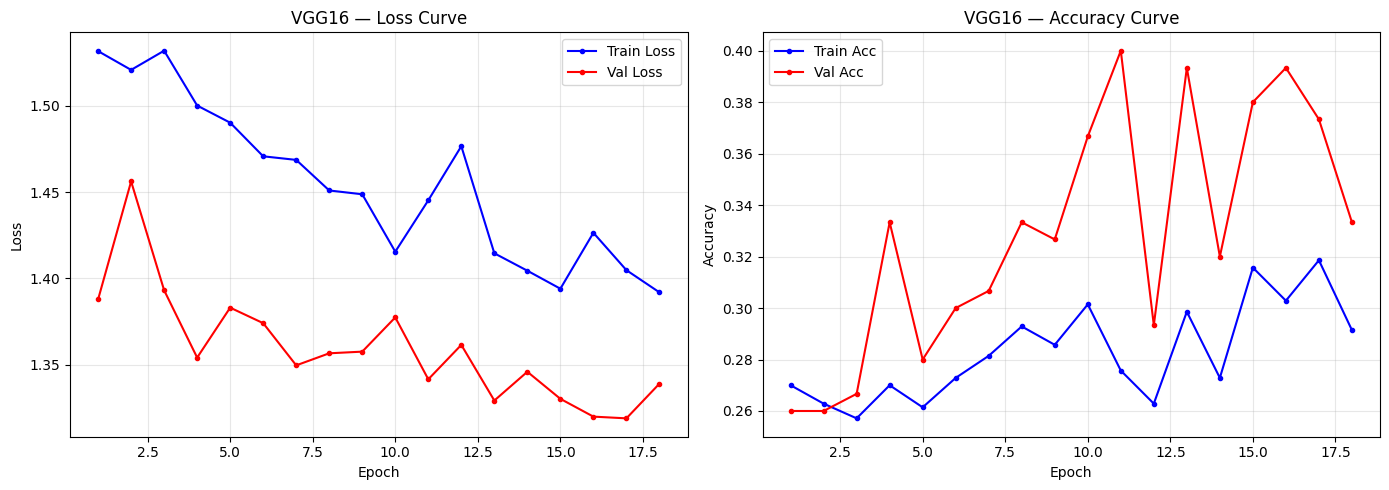

[INFO] Training history saved → training_history_VGG16.png

────────────────────────────────────────────────────────────
  VGG16 — Test Results
────────────────────────────────────────────────────────────
  Accuracy : 30.67%

  Classification Report:
              precision    recall  f1-score   support

       Angry     0.3571    0.4878    0.4124        41
       Other     0.2222    0.0667    0.1026        30
         Sad     0.2745    0.3182    0.2947        44
       happy     0.2941    0.2857    0.2899        35

    accuracy                         0.3067       150
   macro avg     0.2870    0.2896    0.2749       150
weighted avg     0.2912    0.3067    0.2873       150

  Mean Precision : 0.2870
  Mean Recall    : 0.2896
  Mean F1-Score  : 0.2749


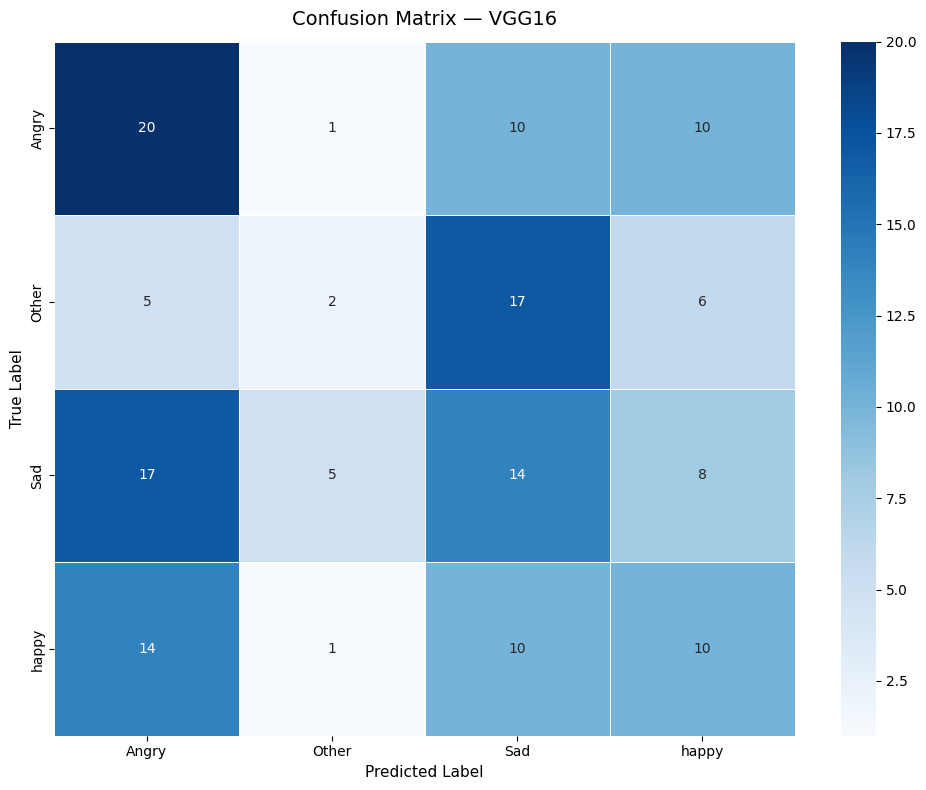

[INFO] Confusion matrix saved → confusion_matrix_VGG16.png

  SUMMARY
  Variant      Accuracy  Precision     Recall         F1
  --------------------------------------------------
  VGG16          30.67%     0.2870     0.2896     0.2749


In [ ]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
import warnings
from torch.utils.data import random_split
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
#  0.  Configuration
# ─────────────────────────────────────────────
NUM_EPOCHS    = 50          # increased — SGD converges slower than Adam
LEARNING_RATE = 0.01        # SGD needs higher LR than Adam
MOMENTUM      = 0.9         # standard momentum used in original VGG paper
WEIGHT_DECAY  = 5e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DEVICE = device

torch.manual_seed(42)
np.random.seed(42)


# ─────────────────────────────────────────────
#  1.  Transforms
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(30),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.9, 1.1)
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# ─────────────────────────────────────────────
#  2.  Dataset — custom find_classes to avoid
#      .ipynb_checkpoints being picked up
# ─────────────────────────────────────────────
VALID_CLASSES = ["Angry", "Other", "Sad", "happy"]


class PetExpressionDataset(datasets.ImageFolder):
    """
    ImageFolder subclass that restricts class discovery to
    VALID_CLASSES only, ignoring system folders like
    .ipynb_checkpoints or any other stray directories.
    """

    def find_classes(self, directory):

        classes = [
            c for c in VALID_CLASSES
            if os.path.isdir(os.path.join(directory, c))
        ]

        if not classes:
            raise FileNotFoundError(
                f"Expected classes {VALID_CLASSES} not found in {directory}"
            )

        class_to_idx = {cls: i for i, cls in enumerate(classes)}

        return classes, class_to_idx


# ─────────────────────────────────────────────
#  3.  Data Loading
# ─────────────────────────────────────────────

# Load without transforms first — used only for splitting indices
full_dataset = PetExpressionDataset(root="./dataset")

dataset_size = len(full_dataset)
train_size   = int(0.7  * dataset_size)
val_size     = int(0.15 * dataset_size)
test_size    = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

# Re-load with transforms applied per split
train_dataset = torch.utils.data.Subset(
    PetExpressionDataset(root="./dataset", transform=train_transform),
    train_subset.indices
)
val_dataset = torch.utils.data.Subset(
    PetExpressionDataset(root="./dataset", transform=val_transform),
    val_subset.indices
)
test_dataset = torch.utils.data.Subset(
    PetExpressionDataset(root="./dataset", transform=test_transform),
    test_subset.indices
)

class_names = full_dataset.classes
num_classes  = len(class_names)

print(f"[INFO] Classes ({num_classes}): {class_names}")
print(f"[INFO] Train : {len(train_dataset):>5} images")
print(f"[INFO] Val   : {len(val_dataset):>5} images")
print(f"[INFO] Test  : {len(test_dataset):>5} images")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)


# ─────────────────────────────────────────────
#  4.  Augmentation Visualisation
# ─────────────────────────────────────────────
def visualize_augmentation_pipeline(dataset, num_samples=3):
    """
    Shows each sample as the original image + 5 augmented versions
    side-by-side to verify the augmentation pipeline.
    """
    fig, axes = plt.subplots(num_samples, 6, figsize=(18, 4 * num_samples))

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for sample_idx in range(num_samples):

        real_idx     = dataset.indices[sample_idx]
        base_dataset = dataset.dataset

        from PIL import Image
        original_path  = base_dataset.samples[real_idx][0]
        original_image = Image.open(original_path).convert('RGB')

        axes[sample_idx, 0].imshow(original_image)
        axes[sample_idx, 0].axis('off')

        class_idx = base_dataset.targets[real_idx]
        axes[sample_idx, 0].text(
            0.5, -0.1,
            f"Class: {base_dataset.classes[class_idx]}",
            transform=axes[sample_idx, 0].transAxes,
            ha='center', fontsize=10
        )
        if sample_idx == 0:
            axes[sample_idx, 0].set_title("Original", fontsize=12, fontweight='bold')

        for aug_idx in range(5):
            aug_image, _ = dataset[sample_idx]

            aug_np = aug_image.numpy().transpose(1, 2, 0)
            aug_np = std * aug_np + mean
            aug_np = np.clip(aug_np, 0, 1)

            axes[sample_idx, aug_idx + 1].imshow(aug_np)
            axes[sample_idx, aug_idx + 1].axis('off')
            if sample_idx == 0:
                axes[sample_idx, aug_idx + 1].set_title(
                    f"Aug {aug_idx+1}", fontsize=12
                )

    plt.suptitle("Data Augmentation Pipeline", fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


visualize_augmentation_pipeline(train_dataset)


# ─────────────────────────────────────────────
#  5.  VGG Architecture (from scratch)
# ─────────────────────────────────────────────
"""
VGG configurations as originally described in:
  "Very Deep Convolutional Networks for Large-Scale Image Recognition"
  Simonyan & Zisserman, 2014.

Key:  integer → Conv2d with that many output channels (3×3, padding=1)
      'M'     → MaxPool2d (2×2, stride=2)
"""
VGG_CONFIGS = {
    "VGG16": [
        64, 64, "M",
        128, 128, "M",
        256, 256, 256, "M",
        512, 512, 512, "M",
        512, 512, 512, "M",
    ],
    "VGG19": [
        64, 64, "M",
        128, 128, "M",
        256, 256, 256, 256, "M",
        512, 512, 512, 512, "M",
        512, 512, 512, 512, "M",
    ],
}


def build_vgg_features(config: list) -> nn.Sequential:
    """
    Constructs the convolutional feature-extractor layers for a VGG variant.

    Args:
        config: List of integers (channels) and 'M' (max-pool) markers.

    Returns:
        nn.Sequential of Conv2d → BatchNorm → ReLU blocks + MaxPool layers.
    """
    layers      = []
    in_channels = 3

    for v in config:
        if v == "M":
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            layers += [
                nn.Conv2d(in_channels, v, kernel_size=3, padding=1),
                nn.BatchNorm2d(v),      # not in original VGG but helps training
                nn.ReLU(inplace=True),
            ]
            in_channels = v

    return nn.Sequential(*layers)


class VGG(nn.Module):
    """
    VGG Network built entirely from scratch.

    Architecture:
      • Feature extractor : Stacked Conv-BN-ReLU blocks + MaxPool
      • Adaptive pooling  : Forces 7×7 output regardless of input size
      • Classifier head   : FC(4096) → FC(4096) → FC(num_classes)
                            with Dropout(0.5) for regularisation

    Args:
        variant     : 'VGG16' or 'VGG19'
        num_classes : Number of output expression classes
    """

    def __init__(self, variant: str = "VGG16", num_classes: int = 4):
        super(VGG, self).__init__()

        assert variant in VGG_CONFIGS, \
            f"variant must be one of {list(VGG_CONFIGS.keys())}"

        self.variant     = variant
        self.num_classes = num_classes

        self.features = build_vgg_features(VGG_CONFIGS[variant])
        self.avgpool  = nn.AdaptiveAvgPool2d((7, 7))

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(4096, num_classes),
        )

        self._initialize_weights()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        """Xavier / Normal weight init for faster, more stable convergence."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.01)
                nn.init.zeros_(m.bias)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ─────────────────────────────────────────────
#  6.  Training & Validation Loops
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Runs one full pass over the training set. Returns avg loss & accuracy."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — important for SGD stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds        = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluates model on a data loader. Returns loss, accuracy, and predictions."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds        = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, \
           np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, num_epochs, device,
                variant_name="VGG"):
    """
    Full training loop with:
      • CrossEntropyLoss
      • SGD + Nesterov momentum (as used in the original VGG paper)
      • Cosine annealing LR scheduler
      • Gradient clipping (max_norm=1.0)
      • Early stopping (patience=7)
      • Best-model checkpoint saved to disk
    """
    criterion = nn.CrossEntropyLoss()

    # SGD with Nesterov momentum — matches original VGG paper training
    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,       # 0.01
        momentum=MOMENTUM,      # 0.9
        weight_decay=WEIGHT_DECAY,
        nesterov=True
    )

    # Cosine annealing: smoothly decays LR from 0.01 → 1e-6 over all epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    best_val_acc = 0.0
    best_weights = None
    patience     = 7
    no_improve   = 0

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   []
    }

    print(f"\n{'='*60}")
    print(f"  Training {variant_name}  |  {model.count_parameters():,} parameters")
    print(f"  Optimizer : SGD  |  LR: {LEARNING_RATE}  |  Momentum: {MOMENTUM}")
    print(f"{'='*60}")

    for epoch in range(1, num_epochs + 1):

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        va_loss, va_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch [{epoch:02d}/{num_epochs}]  "
            f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  "
            f"Val Loss: {va_loss:.4f}  Acc: {va_acc:.4f}  |  "
            f"LR: {lr_now:.2e}"
        )

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, f"best_{variant_name}.pth")
            no_improve   = 0
            print(f"  ✓ New best val accuracy: {best_val_acc:.4f}")
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"[INFO] Early stopping triggered at epoch {epoch}.")
            break

    model.load_state_dict(best_weights)
    print(f"\n[INFO] Best Val Accuracy for {variant_name}: {best_val_acc:.4f}")
    return model, history


# ─────────────────────────────────────────────
#  7.  Evaluation & Reporting
# ─────────────────────────────────────────────
def compute_and_print_metrics(model, test_loader, criterion, device,
                              class_names, variant_name="VGG"):
    """
    Computes and prints:
      • Accuracy
      • Per-class Precision, Recall, F1
      • Mean (macro) Precision, Recall, F1
      • Confusion matrix saved as PNG
    """
    _, test_acc, preds, labels = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\n{'─'*60}")
    print(f"  {variant_name} — Test Results")
    print(f"{'─'*60}")
    print(f"  Accuracy : {test_acc * 100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(
        labels, preds, target_names=class_names, digits=4
    ))

    macro_p  = precision_score(labels, preds, average="macro", zero_division=0)
    macro_r  = recall_score(   labels, preds, average="macro", zero_division=0)
    macro_f1 = f1_score(       labels, preds, average="macro", zero_division=0)

    print(f"  Mean Precision : {macro_p:.4f}")
    print(f"  Mean Recall    : {macro_r:.4f}")
    print(f"  Mean F1-Score  : {macro_f1:.4f}")

    cm = confusion_matrix(labels, preds)
    plot_confusion_matrix(cm, class_names, variant_name)

    return {
        "variant":   variant_name,
        "accuracy":  test_acc,
        "precision": macro_p,
        "recall":    macro_r,
        "f1":        macro_f1,
    }


def plot_confusion_matrix(cm, class_names, variant_name):
    """Saves a styled confusion-matrix heatmap as a PNG file."""
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5
    )
    ax.set_title(f"Confusion Matrix — {variant_name}", fontsize=14, pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label",      fontsize=11)
    plt.tight_layout()
    filename = f"confusion_matrix_{variant_name}.png"
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"[INFO] Confusion matrix saved → {filename}")


def plot_training_history(history, variant_name):
    """Plots and saves loss & accuracy curves for a trained model."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], "b-o", markersize=3, label="Train Loss")
    ax1.plot(epochs, history["val_loss"],   "r-o", markersize=3, label="Val Loss")
    ax1.set_title(f"{variant_name} — Loss Curve")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, history["train_acc"], "b-o", markersize=3, label="Train Acc")
    ax2.plot(epochs, history["val_acc"],   "r-o", markersize=3, label="Val Acc")
    ax2.set_title(f"{variant_name} — Accuracy Curve")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    filename = f"training_history_{variant_name}.png"
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"[INFO] Training history saved → {filename}")


# ─────────────────────────────────────────────
#  8.  Main
# ─────────────────────────────────────────────
def main():

    criterion = nn.CrossEntropyLoss()
    results   = []

    for variant in ["VGG16"]:
        print(f"\n{'#'*60}")
        print(f"  Initialising {variant}")
        print(f"{'#'*60}")

        model = VGG(variant=variant, num_classes=num_classes).to(DEVICE)

        model, history = train_model(
            model, train_loader, val_loader,
            num_epochs=NUM_EPOCHS, device=DEVICE,
            variant_name=variant
        )

        plot_training_history(history, variant)

        metrics = compute_and_print_metrics(
            model, test_loader, criterion, DEVICE,
            class_names, variant_name=variant
        )
        results.append(metrics)

    # Summary table
    print(f"\n{'='*60}")
    print("  SUMMARY")
    print(f"{'='*60}")
    print(f"  {'Variant':<10} {'Accuracy':>10} {'Precision':>10} "
          f"{'Recall':>10} {'F1':>10}")
    print(f"  {'-'*50}")
    for r in results:
        print(f"  {r['variant']:<10} {r['accuracy']*100:>9.2f}% "
              f"{r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f}")


if __name__ == "__main__":
    main()